752


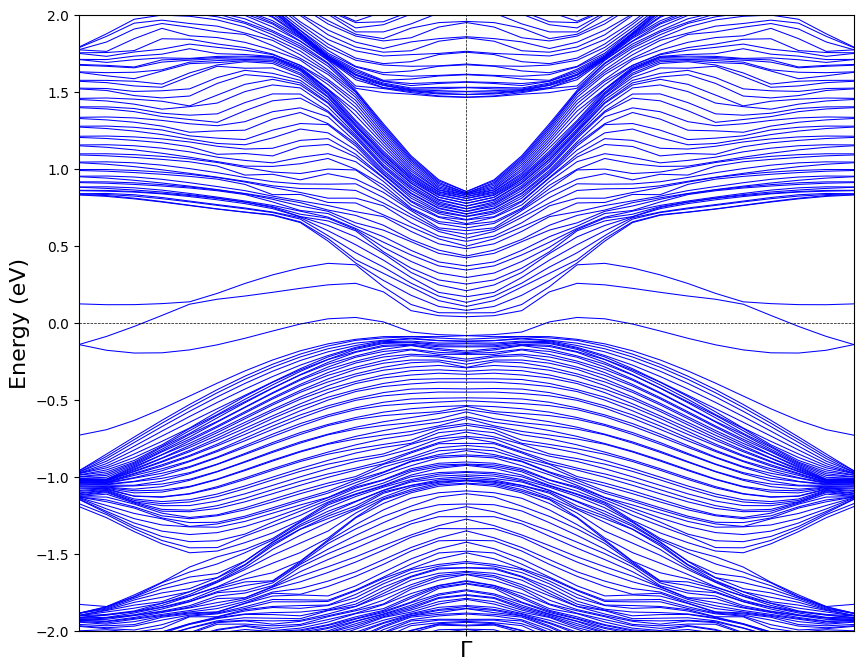

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('strained-bisb-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

# Create the extended k-path: -X to Gamma to X
# The original data goes from Gamma (0) to X (0.737)
k_gamma_to_x = k
bands_gamma_to_x = bands

# For -X to Gamma, we reverse and negate the k-points, and negate the bands
k_minus_x_to_gamma = -k[::-1]
bands_minus_x_to_gamma = bands[::-1, :]

# Concatenate: -X to Gamma, then Gamma to X
# We need to shift k values so they're continuous
k_extended = np.concatenate([k_minus_x_to_gamma, k_gamma_to_x])
bands_extended = np.concatenate([bands_minus_x_to_gamma, bands_gamma_to_x], axis=0)

# Adjust high symmetry points for the new path
high_symmetry_points = [-0.737, 0, 0.737]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k_extended, bands_extended[:, i], color='blue', lw=0.75)

plt.plot(k_extended, bands_extended[:,242], color='red', lw=1)

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel('Energy (eV)', fontsize=16)
plt.xlim(min(k_extended), max(k_extended))
plt.ylim(-2, 2)
plt.show()

583


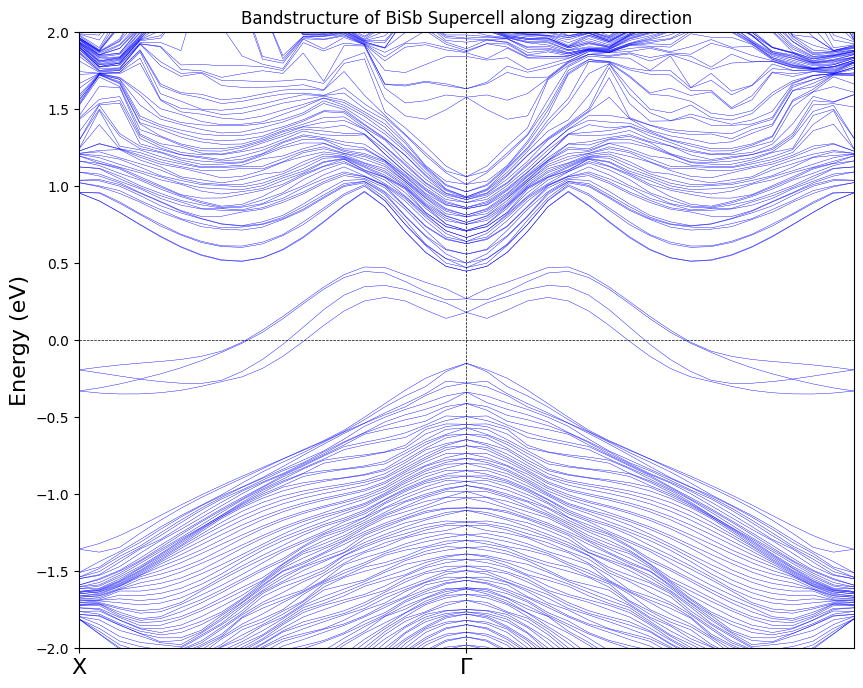

In [34]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('new-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.737,1.475]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.3)

#plt.plot(k, bands[:,479], color='red', lw=1)

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)


plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.title("Bandstructure of BiSb Supercell along zigzag direction")
plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-2, 2)
plt.xlim(min(k), max(k))
plt.show()

583


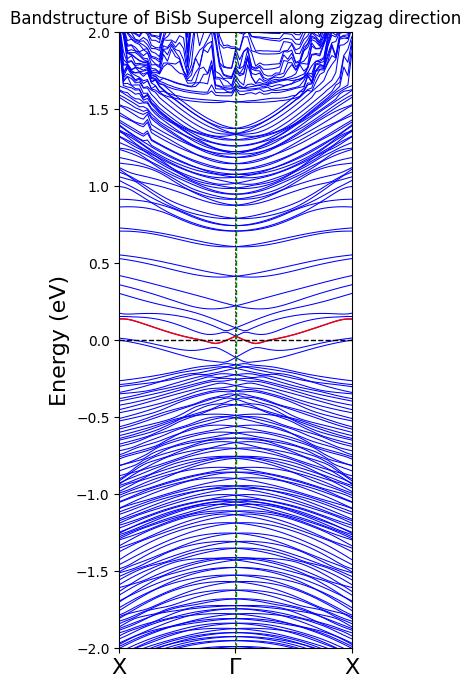

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('strain-14-zoomed-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.147,0.295]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(3, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

plt.plot(k, bands[:,480], color='red', lw=1)

plt.axhline(0, color='black', linestyle='--', lw=1)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.title("Bandstructure of BiSb Supercell along zigzag direction")
plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-2, 2)
plt.xlim(min(k), max(k))
plt.axvline(k[29], color='green', linestyle='--', lw=1)
plt.show()


341


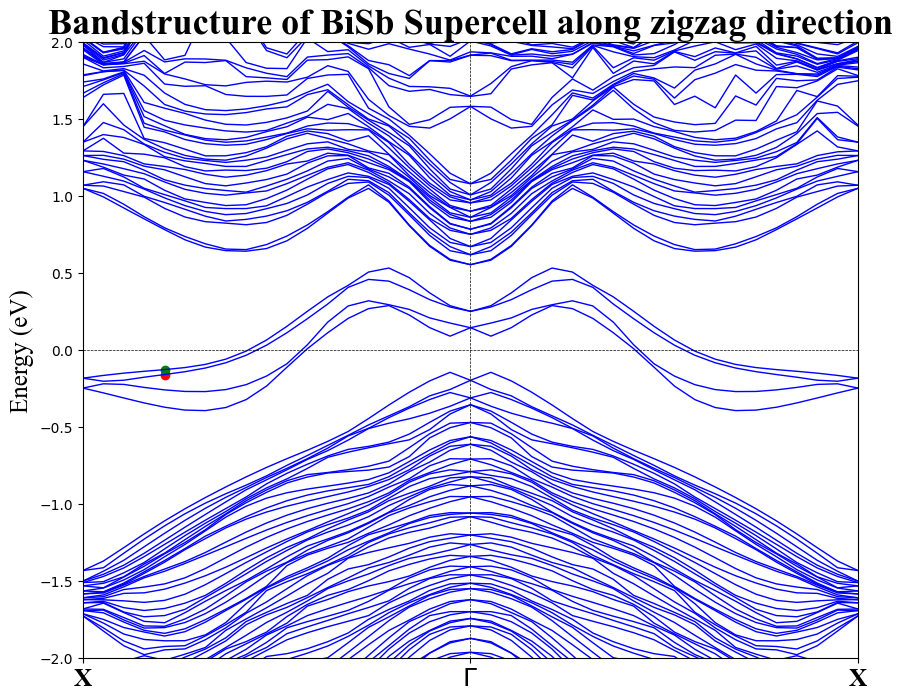

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('short-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.737,max(k)]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=1)

#plt.plot(k, bands[:,280], color='red', lw=1)

plt.scatter(k[4],bands[4,280],c='red')
plt.scatter(k[4],bands[4,281],c='green')

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels,fontsize=18,fontname="Times New Roman", fontweight="bold")
plt.title("Bandstructure of BiSb Supercell along zigzag direction",fontsize=26,fontname="Times New Roman", fontweight="bold")
plt.ylabel('Energy (eV)', fontsize=18,fontname="Times New Roman")
plt.ylim(-2, 2)
plt.xlim(min(k), max(k))
#plt.axvline(k[29], color='green', linestyle='--', lw=1)
plt.show()


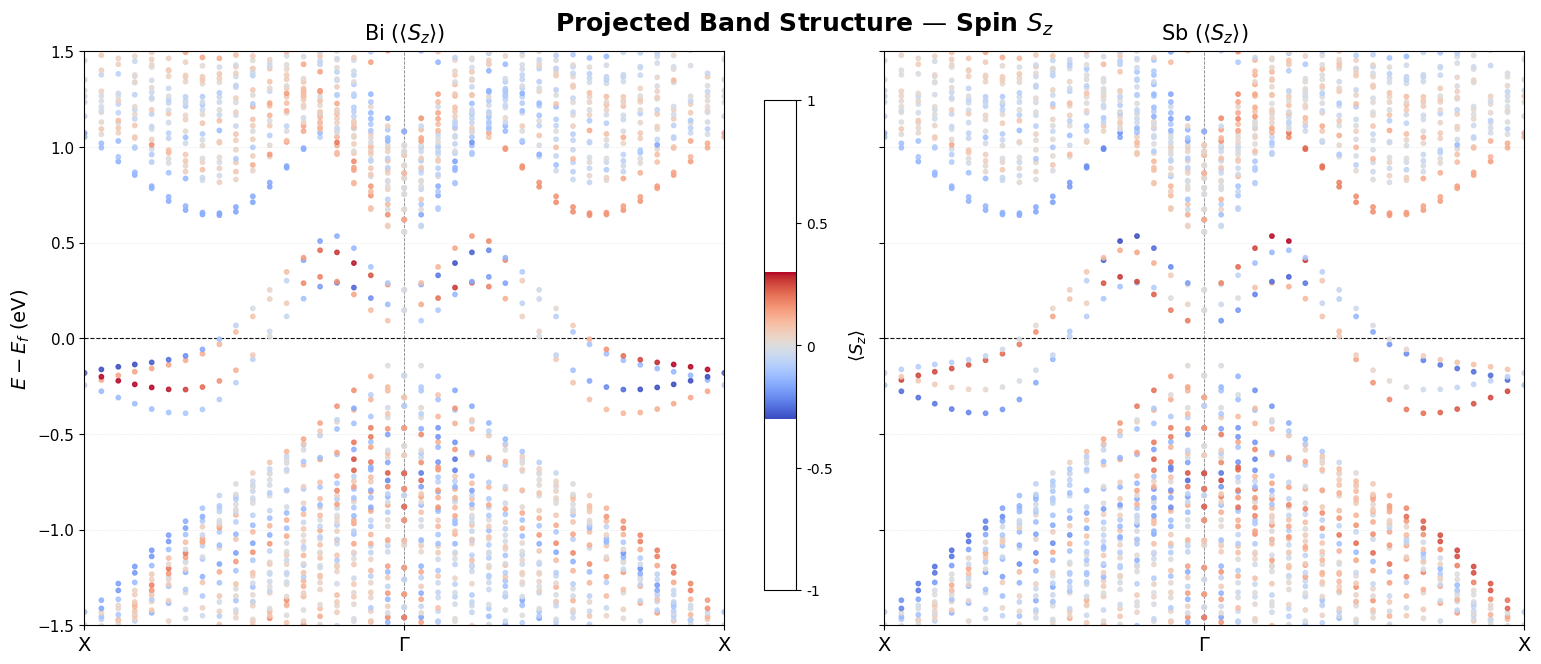

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Load Data ---
def load_band_data(filepath):
    return pd.read_csv(filepath, comment='#', sep=r'\s+', header=None, skiprows=2)

data_bi = load_band_data("short-PBAND_Bi_SOC_SX.dat")
data_sb = load_band_data("short-PBAND_Sb_SOC_SX.dat")

k = data_bi[0].to_numpy()
e = data_bi[1].to_numpy()

# --- High-symmetry k-points and labels ---
k_points = [0,0.737,1.475]  
k_labels = ['X', r'$\Gamma$', 'X']

# --- Normalize to [-1, 1] using global abs max ---
spin_bi = data_bi[11].to_numpy()
spin_sb = data_sb[11].to_numpy()

global_absmax = max(np.abs(spin_bi).max(), np.abs(spin_sb).max())

spin_bi_norm = (spin_bi / global_absmax) 
spin_sb_norm = (spin_sb / global_absmax)

# --- Shared norm and colormap ---
CMAP = 'coolwarm'
shared_norm = Normalize(vmin=-0.3, vmax=0.3)

# --- Plot ---
TITLES = [r'Bi ($\langle S_z \rangle$)', r'Sb ($\langle S_z \rangle$)']
spins  = [spin_bi_norm, spin_sb_norm]

fig = plt.figure(figsize=(16, 7))
fig.suptitle(r"Projected Band Structure — Spin $S_z$", fontsize=18, fontweight='bold')

ax_left  = fig.add_axes([0.05, 0.10, 0.40, 0.82])
ax_right = fig.add_axes([0.55, 0.10, 0.40, 0.82])
ax_cbar  = fig.add_axes([0.475, 0.15, 0.02, 0.70])

axes = [ax_left, ax_right]

for ax, spin, title in zip(axes, spins, TITLES):
    ax.scatter(k, e, c=spin, cmap=CMAP, norm=shared_norm, s=10, alpha=0.85, rasterized=True)

    for xv in k_points[1:-1]:
        ax.axvline(xv, ls='--', lw=0.6, color='gray', zorder=0)

    ax.axhline(0, ls='--', lw=0.8, color='black', zorder=0)
    ax.grid(True, which='major', linestyle=':', linewidth=0.4, alpha=0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlim(k_points[0], k_points[-1])
    ax.set_xticks(k_points)
    ax.set_xticklabels(k_labels, fontsize=14)
    ax.set_title(title, fontsize=15, pad=8)
    ax.tick_params(axis='y', labelsize=11)

ax_left.set_ylabel(r'$E - E_f$ (eV)', fontsize=14)
ax_right.set_yticklabels([])

# --- Centered colorbar ---
sm = ScalarMappable(cmap=CMAP, norm=shared_norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label(r'$\langle S_z \rangle$', fontsize=13, labelpad=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=10)

plt.show()

682


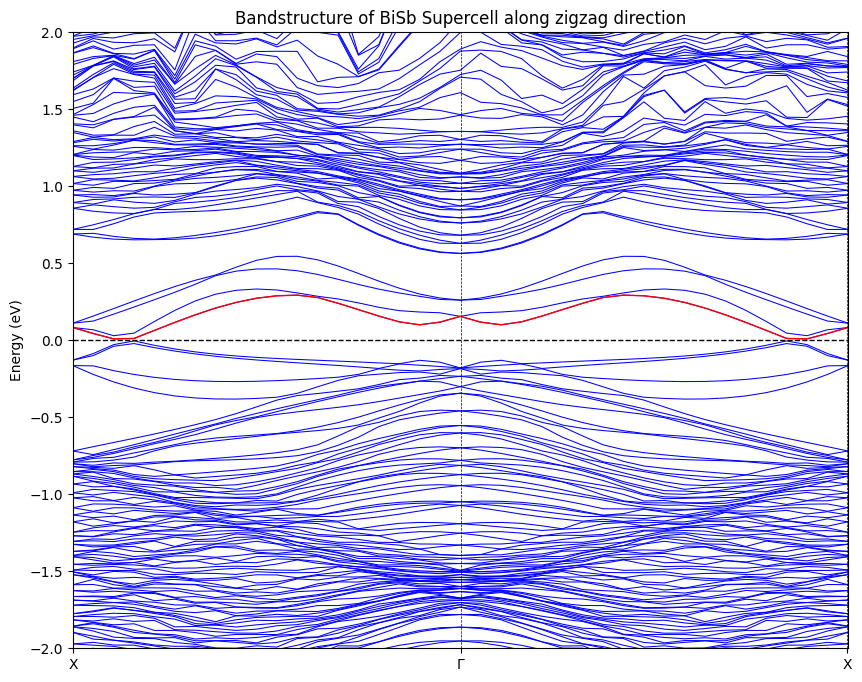

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('2x-short-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.369,0.737]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

plt.plot(k, bands[:,560], color='red', lw=1)

plt.axhline(0, color='black', linestyle='--', lw=1)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels)
plt.title("Bandstructure of BiSb Supercell along zigzag direction")
plt.ylabel('Energy (eV)')
plt.ylim(-2, 2)
plt.xlim(min(k), max(k))
#plt.axvline(k[29], color='green', linestyle='--', lw=1)
plt.show()


Number of bands: 341


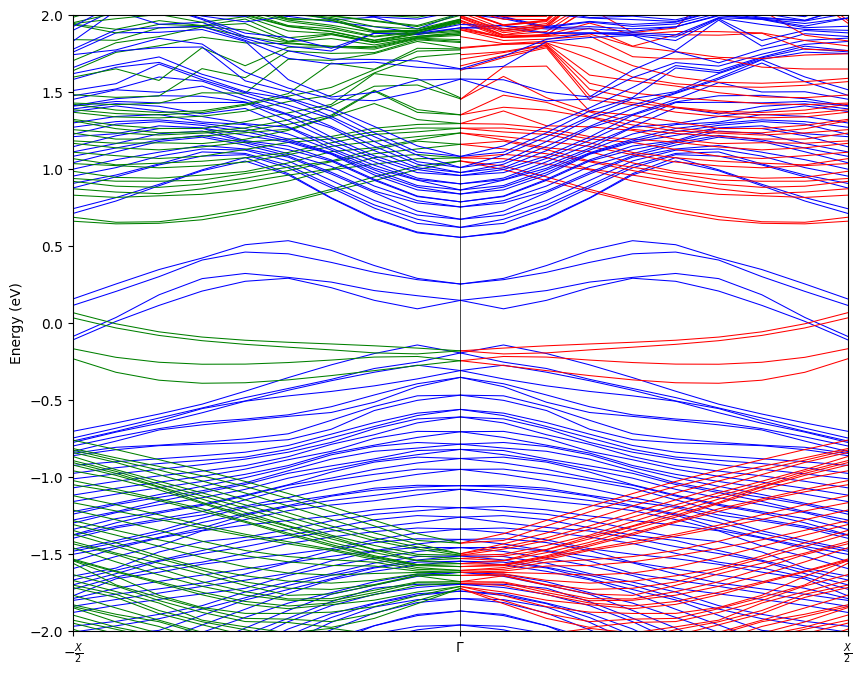

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. LOAD YOUR DATA ---
data = np.loadtxt('short-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(f"Number of bands: {num_bands}")

# Your high symmetry definitions
high_symmetry_points = [0, 0.737, 1.475]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

# --- 2. DIVIDE K-PATH INTO 4 PARTS ---
total_points = len(k)

idx1 = total_points // 4
idx2 = 2 * total_points // 4
idx3 = 3 * total_points // 4

k_part1 = k[:idx1]
k_part2 = k[idx1:idx2]
k_part3 = k[idx2:idx3]
k_part4 = k[idx3:]

bands_part1 = bands[:idx1, :]
bands_part2 = bands[idx1:idx2, :]
bands_part3 = bands[idx2:idx3, :]
bands_part4 = bands[idx3:, :]

# --- 3. CALCULATE SHIFTS AND MOVE BANDS ---
# Shift Part 1 forward to align with Part 3
shift_1_to_3 = k_part3[0] - k_part1[0]
k_part1_moved = k_part1 + shift_1_to_3

# Shift Part 4 backward to align with Part 2
shift_4_to_2 = k_part2[0] - k_part4[0] 
k_part4_moved = k_part4 + shift_4_to_2

# --- 4. PLOT THE DATA ---
plt.figure(figsize=(10, 8))

for b in range(num_bands):
    # Plot Original Parts 2 & 3
    plt.plot(k_part2, bands_part2[:, b], color='blue', lw=0.75, 
             label='Original Parts 2 & 3' if b == 0 else "")
    plt.plot(k_part3, bands_part3[:, b], color='blue', lw=0.75)

    # Plot Moved Part 1
    plt.plot(k_part1_moved, bands_part1[:, b], color='red', lw=0.75, 
             label='Part 1 moved to Part 3' if b == 0 else "")

    # Plot Moved Part 4
    plt.plot(k_part4_moved, bands_part4[:, b], color='green', lw=0.75, 
             label='Part 4 moved to Part 2' if b == 0 else "")

# --- 5. FORMATTING & HIGH SYMMETRY LABELS ---
# Apply your custom high-symmetry ticks

x_labels_folded = [r'$-\frac{X}{2}$',r'$\Gamma$', r'$\frac{X}{2}$']
x_points_folded = [min(k_part2), 0.737, max(k_part3)]  # Use the start of each part for labels

plt.xticks(x_points_folded, x_labels_folded)

# Add a vertical line exactly at the Gamma point
plt.axvline(x=0.737, color='black', linestyle='-', linewidth=0.5)

# Restrict the view strictly to Parts 2 and 3
plt.xlim(k_part2[0], k_part3[-1]) 

plt.ylabel('Energy (eV)')
plt.ylim(-2, 2)

plt.show()

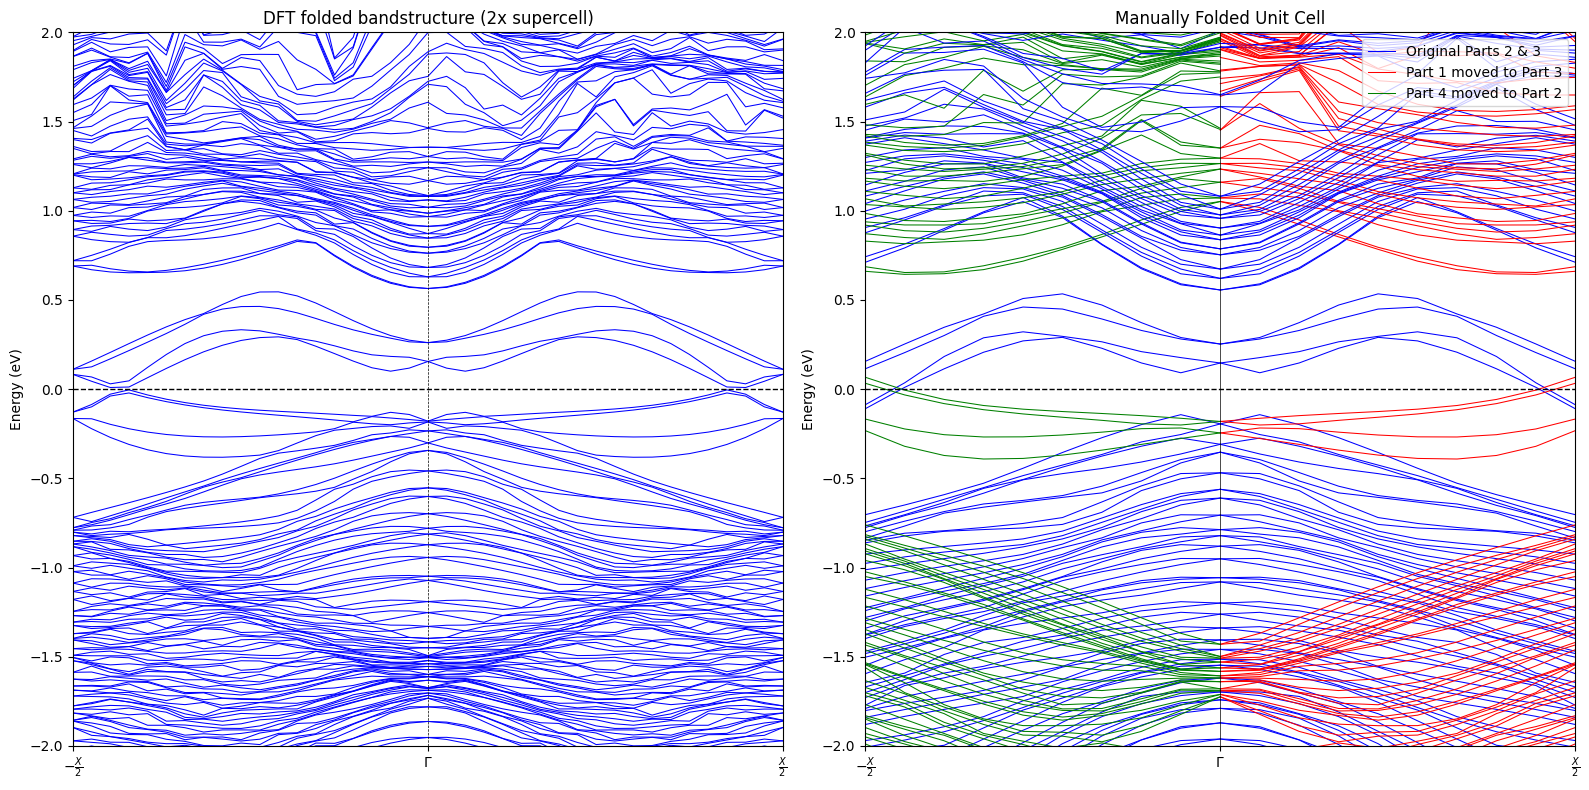

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ==========================================
# PLOT 1: Supercell Bandstructure (ax1)
# ==========================================
data1 = np.loadtxt('2x-short-REFORMATTED_BAND.dat')

k1 = data1[:, 0]
bands1 = data1[:, 1:]
num_bands1 = bands1.shape[1]

high_sym_pts1 = [0, 0.369, 0.737]  
high_sym_lbls1 = [r'$-\frac{X}{2}$', r'$\Gamma$', r'$\frac{X}{2}$']

for i in range(num_bands1):
    ax1.plot(k1, bands1[:, i], color='blue', lw=0.75)

ax1.axhline(0, color='black', linestyle='--', lw=1)

for pt in high_sym_pts1:
    ax1.axvline(pt, color='black', linestyle='--', lw=0.5)

ax1.set_xticks(high_sym_pts1)
ax1.set_xticklabels(high_sym_lbls1)
ax1.set_title("DFT folded bandstructure (2x supercell)")
ax1.set_ylabel('Energy (eV)')
ax1.set_ylim(-2, 2)
ax1.set_xlim(min(k1), max(k1))


# ==========================================
# PLOT 2: Folded Bandstructure (ax2)
# ==========================================
data2 = np.loadtxt('short-REFORMATTED_BAND.dat')

k2 = data2[:, 0]
bands2 = data2[:, 1:]
num_bands2 = bands2.shape[1]

# Divide into 4 parts
total_points = len(k2)
idx1 = total_points // 4
idx2 = 2 * total_points // 4
idx3 = 3 * total_points // 4

k_part1, k_part2 = k2[:idx1], k2[idx1:idx2]
k_part3, k_part4 = k2[idx2:idx3], k2[idx3:]

bands_part1, bands_part2 = bands2[:idx1, :], bands2[idx1:idx2, :]
bands_part3, bands_part4 = bands2[idx2:idx3, :], bands2[idx3:, :]

# Calculate shifts and move
shift_1_to_3 = k_part3[0] - k_part1[0]
k_part1_moved = k_part1 + shift_1_to_3

shift_4_to_2 = k_part2[0] - k_part4[0] 
k_part4_moved = k_part4 + shift_4_to_2

for b in range(num_bands2):
    # Original
    ax2.plot(k_part2, bands_part2[:, b], color='blue', lw=0.75, label='Original Parts 2 & 3' if b == 0 else "")
    ax2.plot(k_part3, bands_part3[:, b], color='blue', lw=0.75)
    # Moved 1 -> 3
    ax2.plot(k_part1_moved, bands_part1[:, b], color='red', lw=0.75, label='Part 1 moved to Part 3' if b == 0 else "")
    # Moved 4 -> 2
    ax2.plot(k_part4_moved, bands_part4[:, b], color='green', lw=0.75, label='Part 4 moved to Part 2' if b == 0 else "")

# Formatting
x_labels_folded = [r'$-\frac{X}{2}$',r'$\Gamma$', r'$\frac{X}{2}$']
x_points_folded = [min(k_part2), 0.737, max(k_part3)] 

ax2.set_xticks(x_points_folded)
ax2.set_xticklabels(x_labels_folded)
ax2.axvline(x=0.737, color='black', linestyle='-', linewidth=0.5)
ax2.axhline(0, color='black', linestyle='--', lw=1) # Added to match left plot

ax2.set_xlim(k_part2[0], k_part3[-1]) 
ax2.set_ylim(-2, 2)
ax2.set_ylabel('Energy (eV)')
ax2.set_title("Manually Folded Unit Cell")
ax2.legend(loc='upper right')

# ==========================================
# FINAL RENDER
# ==========================================
plt.tight_layout()
plt.show()

341


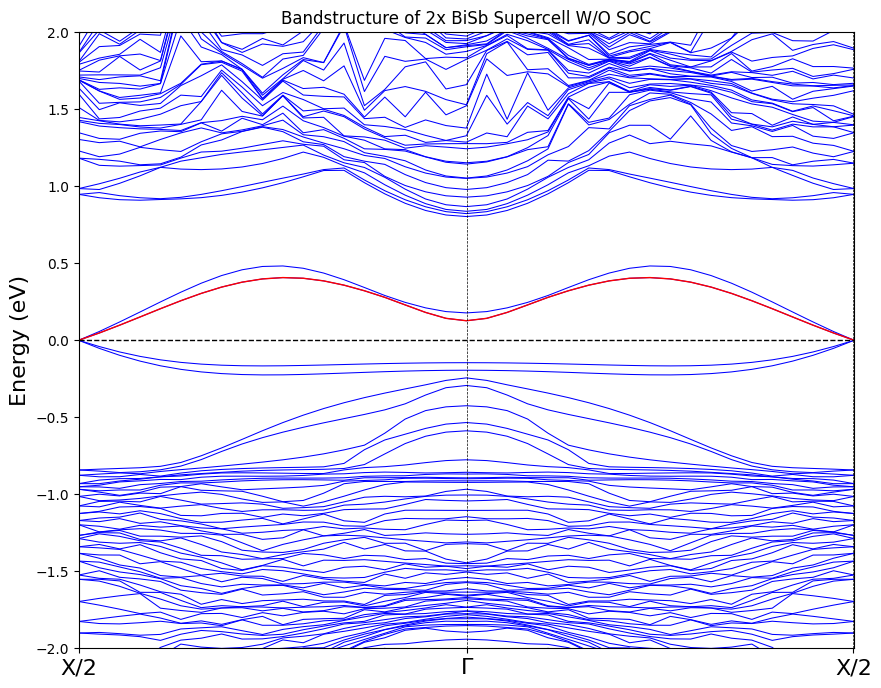

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('wosoc-2x-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.369,0.737]  
high_symmetry_labels = ['X/2', r'$\Gamma$', 'X/2']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

plt.plot(k, bands[:,280], color='red', lw=1)

plt.axhline(0, color='black', linestyle='--', lw=1)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.title("Bandstructure of 2x BiSb Supercell W/O SOC")
plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-2, 2)
plt.xlim(min(k), max(k))
#plt.axvline(k[29], color='green', linestyle='--', lw=1)
plt.show()


176


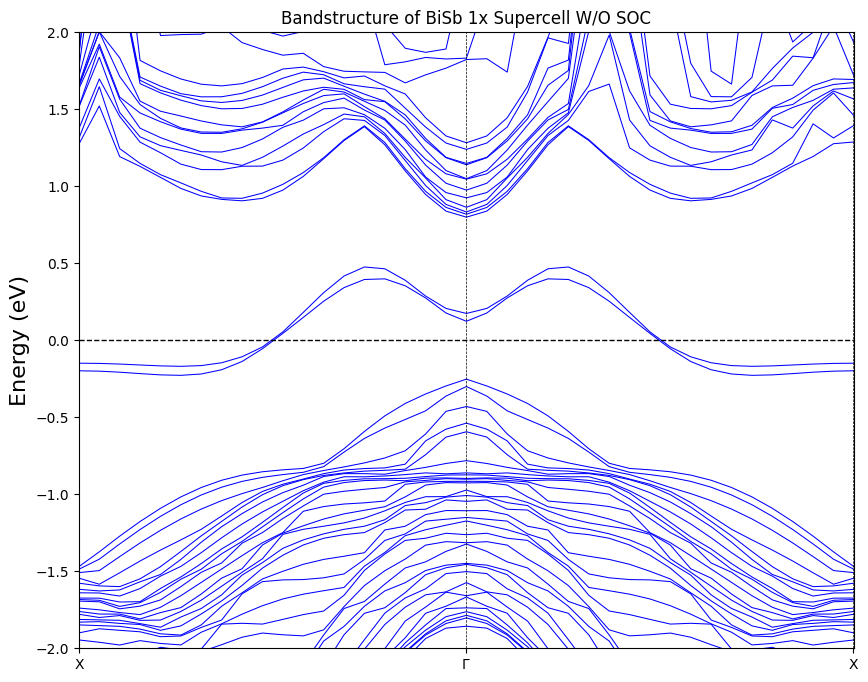

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('wosoc-1x-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.737,1.474]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

#plt.plot(k, bands[:,277], color='red', lw=1)

plt.axhline(0, color='black', linestyle='--', lw=1)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels)
plt.title("Bandstructure of BiSb 1x Supercell W/O SOC")
plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-2, 2)
plt.xlim(min(k), max(k))
#plt.axvline(k[29], color='green', linestyle='--', lw=1)
plt.show()
